# River-Discharge Regime Classification — Exploration Notebook

Interactive exploration of the **river-discharge** dataset (exponential family, 4 populated
hydrological regimes: NG, NV, PC, PN).

This notebook is **distinct** from `classification_notebook.ipynb` (synthetic / CPAZMaL).

**What you can do here:**
1. Load the prebuilt `.npy` dataset from `data/river/`
2. Inspect shapes, class distribution, raw discharge patches
3. Estimate exponential rate parameters per timestep
4. Classify with 4 methods × 2 modes (eucl_params, eucl_raw, wasps, sta)
5. Visualise confusion matrices and barycenters
6. Load and inspect saved `classification_full.json`

Run from the **repo root** with the `.venv` kernel activated.

> **Data source**: prebuilt from NetCDF `dis06` (GRDC/EFAS river discharge, France).  
> Rebuild with `src/data_generator/Explore_2_dataset/build_classification_dataset.py`.

In [ ]:
import sys
from pathlib import Path
import jax

_SRC = Path("../src").resolve()
sys.path.insert(0, str(_SRC))

import jaxconfig  # noqa: F401 — enables JAX x64 (must precede jax.numpy)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay

import distributions
from data.preprocess import clean_time_series
from costs import SqEuclidean, WaSPS
from softdtw import SoftDTW
from classification.barycenter_clf import fit_barycenters, predict
from classification.nn import knn_predict as sdtw_knn
from data.river_loader import load_river_classification

print(f"JAX devices: {jax.devices()}")
print("Imports OK")

---
## 1. Load the dataset

In [3]:
%pwd

'/home/mgallet/Documents/Codes/Python/3_DEVELOPPEMENT/WaSPS-DTW/WaSPS-DTW/analysis'

In [14]:
# ── Configuration knobs ──────────────────────────────────────────────────────
DATA_DIR        = "../data/river"
MODE            = "balanced"    # "balanced" (400 samples) | "basic" (611 samples)
TEST_SIZE       = 0.2           # fraction held out for testing
MAX_TIME_STEPS  = None          # None = all 52 steps; integer = truncate (smoke test)
SEED            = 42
# ─────────────────────────────────────────────────────────────────────────────

data = load_river_classification(
    DATA_DIR, mode=MODE, test_size=TEST_SIZE,
    max_time_steps=MAX_TIME_STEPS, seed=SEED,
)

train_raw    = data["X_train"]    # list of (T, D·W·W) arrays
test_raw     = data["X_test"]
train_labels = data["y_train"]   # (N_train,) int
test_labels  = data["y_test"]
class_names  = data["class_names"]  # {int: str}
metadata     = data["metadata"]

T, D_W2 = train_raw[0].shape
classes  = sorted(set(train_labels.tolist()))

print(f"Train: {len(train_raw)} series   Test: {len(test_raw)} series")
print(f"Shape per series: T={T}, D·W·W={D_W2}")
print(f"Classes (populated): {[class_names.get(c, c) for c in classes]}")
print()
print("Class distribution:")
for cls in classes:
    tr = (train_labels == cls).sum()
    te = (test_labels  == cls).sum()
    print(f"  {class_names.get(cls, cls):4s} (label {cls}):  train={tr}  test={te}")

Train: 320 series   Test: 80 series
Shape per series: T=365, D·W·W=100
Classes (populated): ['NG', 'NP', 'PC', 'PN']

Class distribution:
  NG   (label 0):  train=80  test=20
  NP   (label 1):  train=80  test=20
  PC   (label 3):  train=80  test=20
  PN   (label 5):  train=80  test=20


---
## 2. Inspect raw discharge patches

Each sample is a `(T, D·W·W)` array: T aggregated time periods × D·W·W pixel values
(treated as i.i.d. exponential samples at each timestep t).

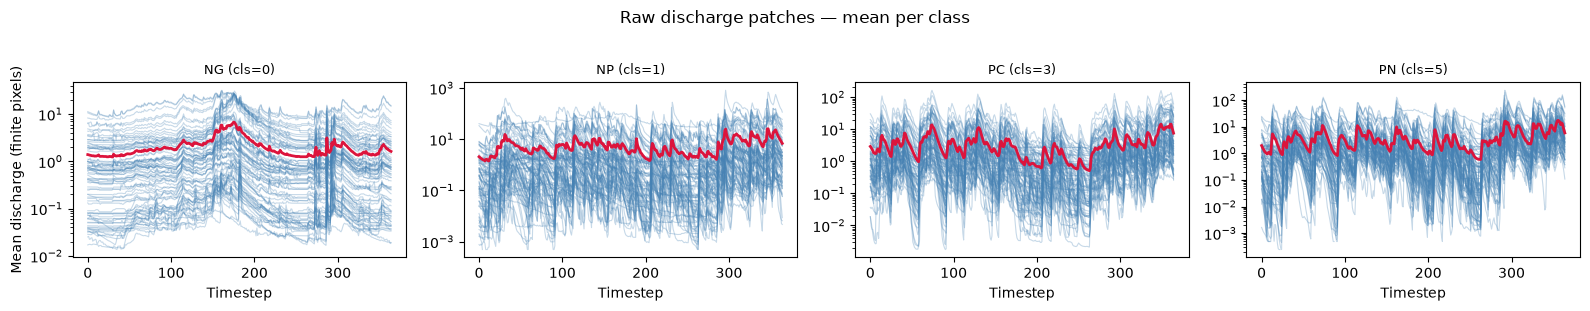

In [15]:
# Plot one sample per class: mean discharge value over time
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 3), sharey=False)
if len(classes) == 1:
    axes = [axes]

for ax, cls in zip(axes, classes):
    cls_idx  = np.where(train_labels == cls)[0]
    cls_data = np.stack([train_raw[i] for i in cls_idx])  # (N_cls, T, D·W·W)

    # Compute finite mean per timestep per sample
    cls_mean = np.array([
        [np.nanmean(s[t][np.isfinite(s[t])]) if np.any(np.isfinite(s[t])) else np.nan
         for t in range(T)]
        for s in [train_raw[i] for i in cls_idx]
    ])  # (N_cls, T)

    for row in cls_mean:
        ax.plot(row, color="steelblue", alpha=0.3, linewidth=0.8)
    ax.semilogy(np.nanmean(cls_mean, 0), color="crimson", linewidth=2, label="class mean")
    ax.set_title(f"{class_names.get(cls, cls)} (cls={cls})", fontsize=9)
    ax.set_xlabel("Timestep")

axes[0].set_ylabel("Mean discharge (finite pixels)")
plt.suptitle("Raw discharge patches — mean per class", y=1.02)
plt.tight_layout()
plt.show()

<cell_type>markdown</cell_type>---
## 3. Parameter estimation (exponential)

`distributions.exponential.fit_time_series(clean_time_series(s))` → `(T, 1)` array of rates β (= 1/mean).  
`clean_time_series` filters NaN and non-positive values per timestep before fitting.

In [ ]:
print("Estimating exponential rate β per timestep …")
dist = distributions.exponential
train_params = [dist.fit_time_series(clean_time_series(s), dtype=np.float64) for s in train_raw]
test_params  = [dist.fit_time_series(clean_time_series(s), dtype=np.float64) for s in test_raw]
print(f"Parameter array shape: {train_params[0].shape}  (T, 1=rate β)")

# Plot mean β over time per class
fig, ax = plt.subplots(figsize=(8, 3))
for cls in classes:
    idx = [i for i, l in enumerate(train_labels) if l == cls]
    cls_params = np.stack([train_params[i] for i in idx])  # (N_cls, T, 1)
    mean_beta  = cls_params[:, :, 0].mean(axis=0)          # (T,)
    ax.semilogy(mean_beta, label=f"{class_names.get(cls, cls)} (cls={cls})")

ax.set_xlabel("Timestep")
ax.set_ylabel("Mean rate β = 1/E[X]")
ax.set_title("Mean estimated exponential rate per class")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Classification hyperparameters

In [ ]:
# ── Classification hyperparameters ───────────────────────────────────────────
GAMMA       = 10.0   # Soft-DTW smoothing
N_STEPS     = 5      # barycenter optimisation steps (reduce for quick exploration)
LR          = 0.05   # adam learning rate
KNN_K       = 1
# ─────────────────────────────────────────────────────────────────────────────

# Two-instance pattern for WaSPS (see classification_notebook.ipynb for explanation)
wasps_cost_bary = WaSPS("exponential", use_positivity_constraint=True)
wasps_cost_knn  = WaSPS("exponential", log_correction=True)

# SoftDTW instances for barycenter fitting
sdtw_eucl  = SoftDTW(SqEuclidean(), GAMMA, is_divergence=True, manual_grad=False)
sdtw_wasps = SoftDTW(wasps_cost_bary, GAMMA, is_divergence=True, manual_grad=True)

print("Config set.  Methods: eucl_params, eucl_raw, wasps  (STA excluded — T=52 is too slow)")

---
## 5. Run all methods

3 methods × 2 modes on the full 320×80 split (~3 min for KNN, ~15 min for barycenters).  
For quick exploration, set `MAX_TIME_STEPS: 8` or `max_train/test_samples: 20` in the config.

**STA excluded**: at T=52, STA KNN costs ~25K Sinkhorn calls (≈17 min). Use
`configs/classification_smoke.yaml` (T=4) to test STA.

In [ ]:
import time

results = {}

# ── eucl_params: SqEuclidean on estimated params ──────────────────────────────
print("[eucl_params] SqEuclidean on params …")
t0 = time.time()
bary_eucl = fit_barycenters(train_params, train_labels, sdtw_eucl, n_steps=N_STEPS, lr=LR)
preds_eucl_bary = predict(test_params, bary_eucl, SqEuclidean(), GAMMA)
results["eucl_params/bary"] = {"preds": preds_eucl_bary, "bary": bary_eucl, "time": time.time() - t0}
preds_eucl_knn = sdtw_knn(train_params, train_labels, test_params,
                           cost_fn=SqEuclidean(), gamma=GAMMA, k=KNN_K)
results["eucl_params/knn"] = {"preds": preds_eucl_knn, "time": 0}
print(f"  bary F1={f1_score(test_labels, preds_eucl_bary, average='weighted', zero_division=0):.3f}  "
      f"knn  F1={f1_score(test_labels, preds_eucl_knn,  average='weighted', zero_division=0):.3f}")

# ── eucl_raw: SqEuclidean on raw samples ──────────────────────────────────────
print("[eucl_raw] SqEuclidean on raw samples …")
t0 = time.time()
preds_raw_knn = sdtw_knn(train_raw, train_labels, test_raw,
                          cost_fn=SqEuclidean(), gamma=GAMMA, k=KNN_K)
results["eucl_raw/knn"] = {"preds": preds_raw_knn, "time": time.time() - t0}
print(f"  knn  F1={f1_score(test_labels, preds_raw_knn, average='weighted', zero_division=0):.3f}")

In [ ]:
# ── wasps: WaSPS W₂² on params (bary + KNN) ──────────────────────────────────
print("[wasps] WaSPS W₂² on params …")
t0 = time.time()
bary_wasps = fit_barycenters(train_params, train_labels, sdtw_wasps, n_steps=N_STEPS, lr=LR)
preds_wasps_bary = predict(test_params, bary_wasps, wasps_cost_knn, GAMMA)
results["wasps/bary"] = {"preds": preds_wasps_bary, "bary": bary_wasps, "time": time.time() - t0}
preds_wasps_knn = sdtw_knn(train_params, train_labels, test_params,
                            cost_fn=wasps_cost_knn, gamma=GAMMA, k=KNN_K)
results["wasps/knn"] = {"preds": preds_wasps_knn, "time": 0}
print(f"  bary F1={f1_score(test_labels, preds_wasps_bary, average='weighted', zero_division=0):.3f}  "
      f"knn  F1={f1_score(test_labels, preds_wasps_knn,  average='weighted', zero_division=0):.3f}")

---
## 6. Results summary

In [ ]:
from sklearn.metrics import accuracy_score

print(f"{'Method':<26} {'Accuracy':>10} {'F1 (weighted)':>15} {'Time (s)':>10}")
print("-" * 65)
for name, res in results.items():
    acc = accuracy_score(test_labels, res["preds"])
    f1  = f1_score(test_labels, res["preds"], average="weighted", zero_division=0)
    print(f"{name:<26} {acc:>10.3f} {f1:>15.3f} {res['time']:>10.1f}")

In [ ]:
# Confusion matrices — one per method
n_methods  = len(results)
regime_labels = [class_names.get(c, str(c)) for c in classes]
fig, axes  = plt.subplots(1, n_methods, figsize=(4.5 * n_methods, 4))
if n_methods == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(test_labels, res["preds"], labels=classes)
    disp = ConfusionMatrixDisplay(cm, display_labels=regime_labels)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle("Confusion matrices — river discharge regimes", y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Barycenter visualisation

WaSPS barycenters represent the **typical exponential rate trajectory** per regime.
Higher β = faster decay / lower expected discharge.

In [ ]:
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 3), sharey=False)
if len(classes) == 1:
    axes = [axes]

for ax, cls in zip(axes, classes):
    idx = [i for i, l in enumerate(train_labels) if l == cls]
    for i in idx:
        ax.semilogy(train_params[i][:, 0], color="steelblue", alpha=0.3, linewidth=0.7)
    mean_p = np.stack([train_params[i][:, 0] for i in idx]).mean(0)
    ax.semilogy(mean_p, color="steelblue", linewidth=1.5, linestyle="--", label="class mean")
    ax.semilogy(bary_wasps[cls][:, 0], color="crimson", linewidth=2, label="wasps bary")
    ax.set_title(f"{class_names.get(cls, cls)}", fontsize=9)
    ax.set_xlabel("Timestep")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Rate β = 1/E[X]")
plt.suptitle("WaSPS barycenters (crimson) vs individual series (blue) — River β", y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Sensitivity to γ

In [ ]:
# Sweep γ for eucl_params and wasps (barycenter methods)
GAMMAS     = [0.1, 0.5, 1.0, 2.0, 5.0]
f1_eucl_g, f1_wasps_g = [], []

for g in GAMMAS:
    sdtw_e = SoftDTW(SqEuclidean(), g, is_divergence=True, manual_grad=False)
    sdtw_w = SoftDTW(WaSPS("exponential", use_positivity_constraint=True), g,
                     is_divergence=True, manual_grad=True)

    b_e = fit_barycenters(train_params, train_labels, sdtw_e, n_steps=N_STEPS, lr=LR)
    p_e = predict(test_params, b_e, SqEuclidean(), g)
    f1_eucl_g.append(f1_score(test_labels, p_e, average="weighted", zero_division=0))

    b_w = fit_barycenters(train_params, train_labels, sdtw_w, n_steps=N_STEPS, lr=LR)
    p_w = predict(test_params, b_w, WaSPS("exponential", log_correction=True), g)
    f1_wasps_g.append(f1_score(test_labels, p_w, average="weighted", zero_division=0))
    print(f"  γ={g:.2f}  eucl_params={f1_eucl_g[-1]:.3f}  wasps={f1_wasps_g[-1]:.3f}")

plt.figure(figsize=(6, 3))
plt.plot(GAMMAS, f1_eucl_g, "o-", label="eucl_params")
plt.plot(GAMMAS, f1_wasps_g, "s-", label="wasps")
plt.xlabel("γ (Soft-DTW regularisation)")
plt.ylabel("F1 weighted")
plt.xscale("log")
plt.legend()
plt.title("River discharge — Sensitivity to γ")
plt.tight_layout()
plt.show()

---
## 9. Interactive: classify a custom sample

Replace `CUSTOM_RATE` with any exponential rate to see how the trained
classifiers assign it to a regime.

In [ ]:
rng = np.random.default_rng(SEED + 1)

CUSTOM_RATE = 2.0   # modify: higher β ≈ lower expected discharge
n_pixels    = train_raw[0].shape[1]
T_          = train_raw[0].shape[0]

custom_raw    = rng.exponential(1.0 / CUSTOM_RATE, (T_, n_pixels))
custom_params = distributions.exponential.fit_time_series(
    clean_time_series(custom_raw), dtype=np.float64
)

pred_eucl_bary  = predict([custom_params], bary_eucl, SqEuclidean(), GAMMA)[0]
pred_wasps_bary = predict([custom_params], bary_wasps, wasps_cost_knn, GAMMA)[0]
pred_wasps_knn  = sdtw_knn(train_params, train_labels, [custom_params],
                            cost_fn=wasps_cost_knn, gamma=GAMMA, k=KNN_K)[0]

print(f"Custom series (rate β={CUSTOM_RATE}):")
print(f"  eucl_params/bary → {class_names.get(pred_eucl_bary, pred_eucl_bary)}")
print(f"  wasps/bary       → {class_names.get(pred_wasps_bary, pred_wasps_bary)}")
print(f"  wasps/knn        → {class_names.get(pred_wasps_knn,  pred_wasps_knn)}")

---
## 10. Load saved classification results

If you ran `python experiments/run_classification.py configs/river.yaml`, load
the serialised results here for further analysis.

In [ ]:
import json

result_path = Path("../results/jax_river/classification_full.json")
if result_path.exists():
    with open(result_path) as f:
        saved = json.load(f)
    ds = saved["config"]["dataset"]
    print(f"Dataset: type={ds['type']}  family={ds['family']}  mode={ds.get('mode')}")
    print()
    print(f"{'Method':12s}  {'Mode':10s}  {'F1 mean':>8}  {'F1 std':>7}  {'Acc mean':>9}")
    print("-" * 55)
    for r in saved["summary"]:
        print(f"  {r['method']:12s}/{r['mode']:10s}  "
              f"f1={r['f1_mean']:.3f}±{r['f1_std']:.3f}  "
              f"acc={r['acc_mean']:.3f}±{r['acc_std']:.3f}")
else:
    print(f"{result_path} not found.")
    print("Run:  python experiments/run_classification.py configs/river.yaml")